# 07 Baseline D1: Decade-Conditioned Baseline

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '07_baseline_d1_decade'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
def standardize_edges(edges):
    out = edges[['citing_paper_id', 'cited_paper_id']].copy()
    out['citing_paper_id'] = out['citing_paper_id'].astype(str)
    out['cited_paper_id'] = out['cited_paper_id'].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
    cs_papers = pd.read_pickle(PROCESSED_DIR / 'cs_papers_final.pkl')
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl'))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl'))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl'))
    papers['id'] = papers['id'].astype(str)
    cs_papers['id'] = cs_papers['id'].astype(str)
    return (papers, cs_papers, all_edges, all_to_cs, cs_to_cs)

def known_cs(cs_papers):
    return cs_papers[cs_papers['first_last_cat'].isin(GENDER_CATEGORIES)].copy()

def aggregate_oe(observed, expected, baseline, citation_slice):
    rows = []
    for g in GENDER_CATEGORIES:
        o = float(observed.get(g, 0.0))
        e = float(expected.get(g, 0.0))
        oe = o / e if e > 0 else np.nan
        rows.append({'gender_cat': g, 'observed_citations': o, 'expected_citations': e, 'oe_ratio': oe, 'pct_diff_from_expected': (oe - 1.0) * 100 if pd.notna(oe) else np.nan, 'baseline': baseline, 'citation_slice': citation_slice})
    return pd.DataFrame(rows)

def prepare_cited_edges(edges, cs_known, extra_cols):
    meta_cols = ['id', 'first_last_cat'] + list(extra_cols)
    meta = cs_known[meta_cols].drop_duplicates('id').rename(columns={'id': 'cited_paper_id', 'first_last_cat': 'cited_gender'})
    return edges.merge(meta, on='cited_paper_id', how='inner')

In [3]:
def stratified_expected(cs_known, edges, strata_cols, baseline_name, citation_slice):
    shares = cs_known.groupby(strata_cols + ['first_last_cat'], dropna=False).size().rename('n').reset_index()
    totals = shares.groupby(strata_cols, dropna=False)['n'].transform('sum')
    shares['share'] = shares['n'] / totals
    share_wide = shares.pivot_table(index=strata_cols, columns='first_last_cat', values='share', fill_value=0, dropna=False).reindex(columns=GENDER_CATEGORIES, fill_value=0).reset_index()
    cited = prepare_cited_edges(edges, cs_known, strata_cols)
    cited = cited.merge(share_wide, on=strata_cols, how='left')
    observed = cited['cited_gender'].value_counts().reindex(GENDER_CATEGORIES, fill_value=0)
    expected = cited[GENDER_CATEGORIES].sum().reindex(GENDER_CATEGORIES, fill_value=0)
    result = aggregate_oe(observed, expected, baseline_name, citation_slice)
    return (result, cited, share_wide)

## 1. Load final data

In [4]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
cs_known = known_cs(cs_papers)
print('Final papers:', papers.shape)
print('Known-gender CS papers:', cs_known.shape)
print('Final edges:', citation_edges_final.shape)

Final papers: (3026412, 29)
Known-gender CS papers: (1081363, 29)
Final edges: (18904534, 2)


## 2. Compute D1

In [5]:
d1_all, d1_all_edges, d1_shares = stratified_expected(cs_known, edges_all_to_cs, ['decade'], 'D1_decade', 'All→CS')
d1_cs, d1_cs_edges, _ = stratified_expected(cs_known, edges_cs_to_cs, ['decade'], 'D1_decade', 'CS→CS')
d1_results = pd.concat([d1_all, d1_cs], ignore_index=True)
d1_results

,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice
0,MM,"6,942,653.0000","6,666,725.6879",1.0414,4.1389,D1_decade,All→CS
1,MW,"641,435.0000","683,708.0811",0.9382,-6.1829,D1_decade,All→CS
2,WM,"812,529.0000","919,069.9396",0.8841,-11.5923,D1_decade,All→CS
3,WW,"289,620.0000","416,733.2915",0.6950,-30.5023,D1_decade,All→CS
4,MM,"5,601,920.0000","5,393,287.8902",1.0387,3.8684,D1_decade,CS→CS
5,MW,"529,022.0000","552,024.8202",0.9583,-4.1670,D1_decade,CS→CS
6,WM,"662,200.0000","741,500.5949",0.8931,-10.6946,D1_decade,CS→CS
7,WW,"230,358.0000","336,686.6946",0.6842,-31.5809,D1_decade,CS→CS


## 3. Decade diagnostics

In [6]:
d1_by_decade = d1_all_edges.groupby(['decade', 'cited_gender']).size().rename('observed').reset_index().merge(d1_shares.melt(id_vars=['decade'], value_vars=GENDER_CATEGORIES, var_name='cited_gender', value_name='paper_share'), on=['decade', 'cited_gender'], how='left')
d1_by_decade['total_edges_decade'] = d1_by_decade.groupby('decade')['observed'].transform('sum')
d1_by_decade['expected'] = d1_by_decade['paper_share'] * d1_by_decade['total_edges_decade']
d1_by_decade['oe_ratio'] = d1_by_decade['observed'] / d1_by_decade['expected'].replace(0, np.nan)
d1_by_decade

,decade,cited_gender,observed,paper_share,total_edges_decade,expected,oe_ratio
0,1950,MM,10063,0.9665,10809,"10,447.2815",0.9632
1,1950,MW,656,0.0138,10809,148.9429,4.4044
2,1950,WW,90,0.0197,10809,212.7756,0.4230
3,1960,MM,63099,0.9576,64953,"62,199.6519",1.0145
4,1960,MW,1055,0.0103,64953,672.0771,1.5698
5,1960,WM,165,0.0063,64953,411.9182,0.4006
6,1960,WW,634,0.0257,64953,"1,669.3528",0.3798
7,1970,MM,219780,0.9300,233176,"216,865.0151",1.0134
8,1970,MW,4058,0.0184,233176,"4,284.2752",0.9472
9,1970,WM,4393,0.0166,233176,"3,880.8233",1.1320


## 4. Visualize

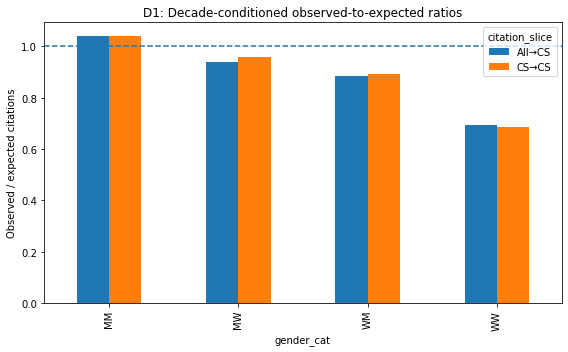

In [7]:
plot = d1_results.pivot(index='gender_cat', columns='citation_slice', values='oe_ratio').reindex(GENDER_CATEGORIES)
ax = plot.plot(kind='bar', figsize=(8, 5))
ax.axhline(1.0, linestyle='--')
ax.set_ylabel('Observed / expected citations')
ax.set_title('D1: Decade-conditioned observed-to-expected ratios')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_d1_decade_slice_comparison.png', dpi=300)
plt.show()

## 5. Save outputs

In [8]:
d1_all.to_csv(TABLE_DIR / 'baseline_d1_decade_all_to_cs.csv', index=False)
d1_cs.to_csv(TABLE_DIR / 'baseline_d1_decade_cs_to_cs.csv', index=False)
d1_results.to_csv(TABLE_DIR / 'baseline_d1_decade_slice_comparison.csv', index=False)
d1_results.to_csv(TABLE_DIR / 'd1_decade_oe_by_gender.csv', index=False)
d1_by_decade.to_csv(TABLE_DIR / 'd1_all_to_cs_by_decade.csv', index=False)
print('Saved:', NOTEBOOK_OUTPUT_DIR)

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\07_baseline_d1_decade
